In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:02<00:00, 61.0MB/s]


In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [4]:
from torchvision import models

model_tl = models.resnet18(pretrained=True)

# Freeze layers
for param in model_tl.parameters():
    param.requires_grad = False

# Replace final layer
model_tl.fc = nn.Linear(model_tl.fc.in_features, 10)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]


In [5]:
def train_model(model, trainloader, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_loss = []
    start_time = time.time()

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)
        train_loss.append(epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

    total_time = time.time() - start_time
    return train_loss, total_time

In [6]:
def evaluate(model, testloader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100 * correct / total
    print("Accuracy:", acc)

    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True)
    plt.show()

    return acc


--- Training CNN ---
Epoch 1, Loss: 1.4141
Epoch 2, Loss: 1.0598
Epoch 3, Loss: 0.9145
CNN Accuracy: 65.05% | Time: 252.11s

--- Training ResNet18 ---
Epoch 1, Loss: 1.7574
ResNet18 Accuracy: 42.14% | Time: 146.40s


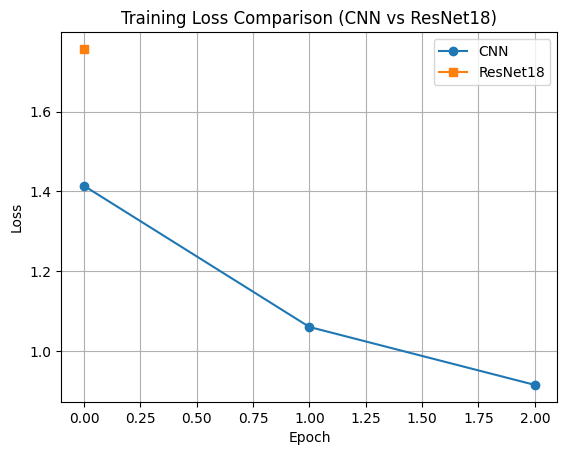

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

# ------------------ Simple CNN ------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),  # for CIFAR-10 (32x32)
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x


# ------------------ Data ------------------
transform = transforms.Compose([
    transforms.ToTensor()  # keep 32x32 → fast
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)


# ------------------ Train Function ------------------
def train_model(model, dataloader, epochs=1):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    losses = []
    start = time.time()

    for epoch in range(epochs):
        running_loss = 0
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(dataloader)
        losses.append(epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

    return losses, time.time() - start


# ------------------ Evaluation ------------------
def evaluate(model, dataloader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = 100 * correct / total

    return acc, all_labels, all_preds


# ------------------ Train CNN ------------------
print("\n--- Training CNN ---")
cnn = SimpleCNN()
loss_cnn, time_cnn = train_model(cnn, trainloader, epochs=3)
acc_cnn, labels_cnn, preds_cnn = evaluate(cnn, testloader)

print(f"CNN Accuracy: {acc_cnn:.2f}% | Time: {time_cnn:.2f}s")


# ------------------ ResNet18 ------------------
from torchvision import models

print("\n--- Training ResNet18 ---")

model_tl = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze pretrained layers
for param in model_tl.parameters():
    param.requires_grad = False

model_tl.fc = nn.Linear(model_tl.fc.in_features, 10)

loss_resnet, time_resnet = train_model(model_tl, trainloader, epochs=1)
acc_resnet, labels_resnet, preds_resnet = evaluate(model_tl, testloader)

print(f"ResNet18 Accuracy: {acc_resnet:.2f}% | Time: {time_resnet:.2f}s")


# ------------------ Loss Comparison ------------------
plt.figure()
plt.plot(loss_cnn, marker='o', label="CNN")
plt.plot(loss_resnet, marker='s', label="ResNet18")
plt.title("Training Loss Comparison (CNN vs ResNet18)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

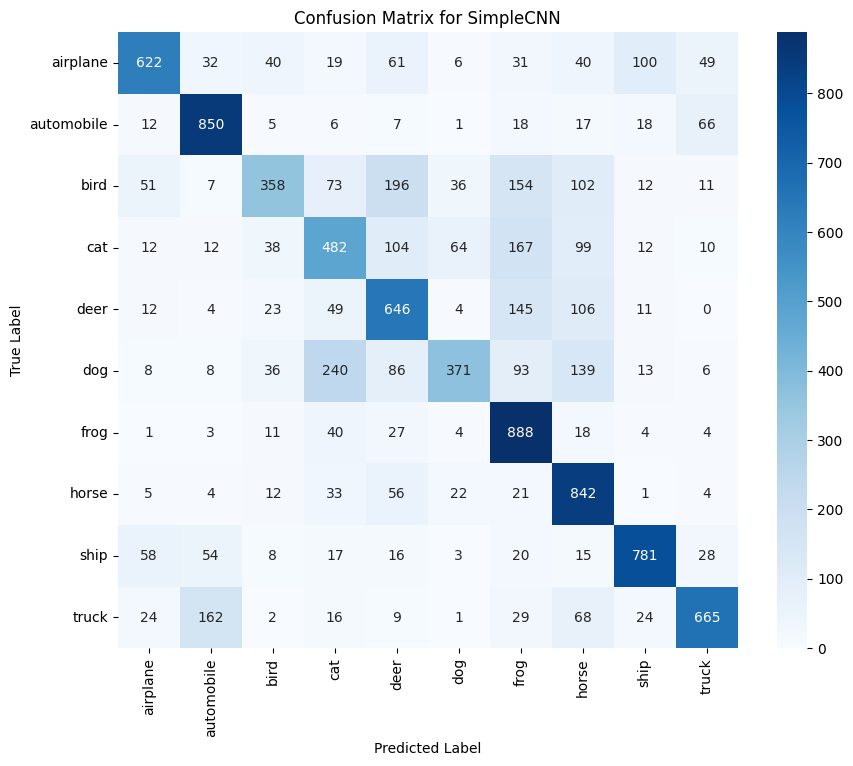

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming 'classes' variable is available from previous data loading for CIFAR-10
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Generate confusion matrix for SimpleCNN
cm_cnn = confusion_matrix(labels_cnn, preds_cnn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix for SimpleCNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [1]:
!pip uninstall -y torch torchvision torchtext
!pip install torch==2.3.0 torchvision==0.18.0 torchtext==0.18.0

Found existing installation: torch 2.3.0
Uninstalling torch-2.3.0:
  Successfully uninstalled torch-2.3.0
Found existing installation: torchvision 0.18.0
Uninstalling torchvision-0.18.0:
  Successfully uninstalled torchvision-0.18.0
Found existing installation: torchtext 0.18.0
Uninstalling torchtext-0.18.0:
  Successfully uninstalled torchtext-0.18.0
  Using cached torch-2.3.0-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached torchvision-0.18.0-cp312-cp312-manylinux1_x86_64.whl.metadata (6.6 kB)
  Using cached torchtext-0.18.0-cp312-cp312-manylinux1_x86_64.whl.metadata (7.9 kB)
Using cached torch-2.3.0-cp312-cp312-manylinux1_x86_64.whl (779.1 MB)
Using cached torchvision-0.18.0-cp312-cp312-manylinux1_x86_64.whl (7.0 MB)
Using cached torchtext-0.18.0-cp312-cp312-manylinux1_x86_64.whl (2.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch

In [2]:
import torchtext
print(f"torchtext version: {torchtext.__version__}")

torchtext version: 0.18.0+cpu


In [3]:
from torchtext.datasets import IMDB
from torchtext.data.utils import get_tokenizer
from collections import Counter

/usr/local/lib/python3.12/dist-packages/torchtext/datasets/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


In [5]:
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.rnn(x)
        return self.fc(hidden.squeeze(0))

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        return self.fc(hidden.squeeze(0))

In [7]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.gru(x)
        return self.fc(hidden.squeeze(0))

In [8]:
class Generator(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

In [9]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [10]:
def train_gan(generator, discriminator, dataloader, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    generator.to(device)
    discriminator.to(device)

    criterion = nn.BCELoss()
    opt_g = optim.Adam(generator.parameters(), lr=0.0002)
    opt_d = optim.Adam(discriminator.parameters(), lr=0.0002)

    for epoch in range(epochs):
        for real, _ in dataloader:
            real = real.view(-1, 784).to(device)
            batch_size = real.size(0)

            # Train Discriminator
            z = torch.randn(batch_size, 100).to(device)
            fake = generator(z)

            loss_d = criterion(discriminator(real), torch.ones(batch_size, 1).to(device)) + \
                     criterion(discriminator(fake.detach()), torch.zeros(batch_size, 1).to(device))

            opt_d.zero_grad()
            loss_d.backward()
            opt_d.step()

            # Train Generator
            loss_g = criterion(discriminator(fake), torch.ones(batch_size, 1).to(device))

            opt_g.zero_grad()
            loss_g.backward()
            opt_g.step()

        print(f"Epoch {epoch+1}, D Loss: {loss_d.item()}, G Loss: {loss_g.item()}")

In [12]:
import torchvision.transforms as transforms
import torchvision.datasets
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_dataloader = DataLoader(mnist_dataset, batch_size=64, shuffle=True)
print("MNIST dataset and DataLoader prepared.")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:00<00:00, 58297382.72it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 1702850.75it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 14413542.18it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 10122491.38it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

MNIST dataset and DataLoader prepared.


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

z_dim = 100
generator = Generator(z_dim)
discriminator = Discriminator()

print("Training GAN...")
train_gan(generator, discriminator, mnist_dataloader, epochs=10)
print("GAN training complete.")

Training GAN...
Epoch 1, D Loss: 1.0228590965270996, G Loss: 0.8108373284339905
Epoch 2, D Loss: 1.5092397928237915, G Loss: 0.7425126433372498
Epoch 3, D Loss: 0.4162810444831848, G Loss: 1.6007598638534546
Epoch 4, D Loss: 1.0986082553863525, G Loss: 0.9879864454269409
Epoch 5, D Loss: 0.6433843374252319, G Loss: 1.4190274477005005
Epoch 6, D Loss: 1.315432071685791, G Loss: 0.7858525514602661
Epoch 7, D Loss: 0.9785478115081787, G Loss: 0.9738925695419312
Epoch 8, D Loss: 1.1953623294830322, G Loss: 0.9073625206947327
Epoch 9, D Loss: 1.373121738433838, G Loss: 0.8885210752487183
Epoch 10, D Loss: 1.2931253910064697, G Loss: 0.8526701927185059
GAN training complete.


In [15]:
batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create a random noise vector
z = torch.randn(batch_size, z_dim).to(device)

# Set the generator to evaluation mode
generator.eval()

# Generate fake images
with torch.no_grad():
    fake_images_tensor = generator(z)

# Move to CPU and convert to NumPy array
fake_images_numpy = fake_images_tensor.cpu().numpy()

print(f"Generated fake images shape: {fake_images_numpy.shape}")

Generated fake images shape: (16, 784)


In [16]:
fake_images_reshaped = fake_images_numpy.reshape(batch_size, 28, 28)
print(f"Reshaped fake images shape: {fake_images_reshaped.shape}")

Reshaped fake images shape: (16, 28, 28)


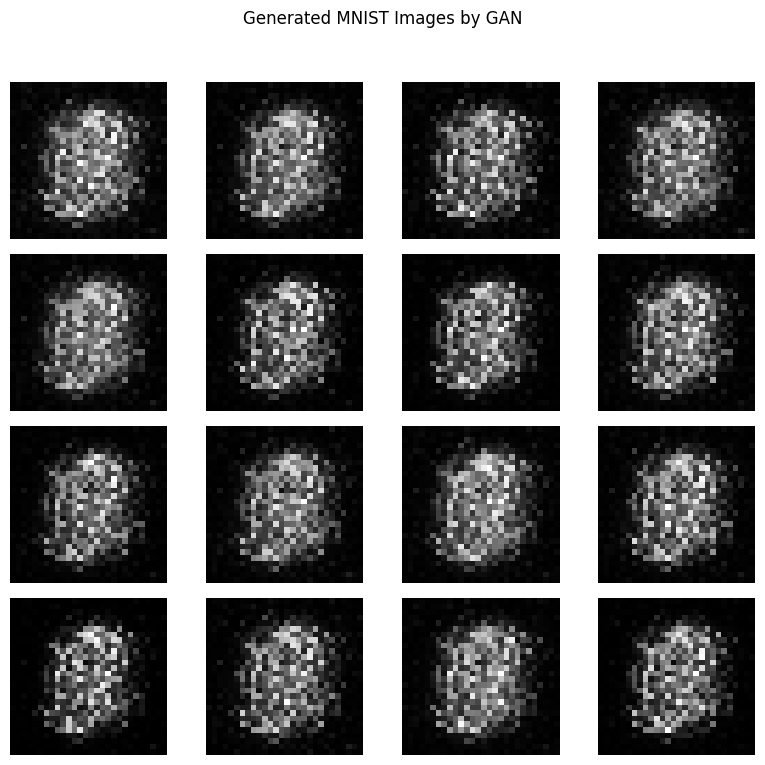

In [17]:
import matplotlib.pyplot as plt

# Create a figure and a 4x4 grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.flatten()

# Iterate through the reshaped fake images and display them
for i in range(batch_size):
    axes[i].imshow(fake_images_reshaped[i], cmap='gray')
    axes[i].axis('off') # Turn off axis

plt.suptitle('Generated MNIST Images by GAN')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()
